Import the libraries.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

### I. Mean Imputation.

Read the dataset.

In [2]:
df = pd.read_csv('Datasets/titanic_toy.csv')
df.sample(5)

,Age,Fare,Family,Survived
639,NaN,16.1000,1,0
192,19.0,7.8542,1,1
90,29.0,8.0500,0,0
486,35.0,90.0000,1,1
858,24.0,19.2583,3,1


Check the null and non-null values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [4]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

Split the data into train and test.

In [5]:
x = df.drop('Survived', axis=1)
y = df['Survived']

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 3), (179, 3), (712,), (179,))

Percent of null values present in the data.

In [7]:
x_train.isnull().mean()*100

Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64

Store mean and median of age and fare. 

In [8]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()
mean_age, median_age

(np.float64(29.498846153846156), np.float64(28.0))

In [9]:
mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()
mean_fare, median_fare

(np.float64(32.51778772189349), np.float64(14.4))

Replace the null values by mean and median of age and fare.

In [10]:
x_train['Mean_age'] = x_train['Age'].fillna(mean_age)
x_train['Median_age'] = x_train['Age'].fillna(median_age)
x_train['Mean_fare'] = x_train['Fare'].fillna(mean_fare)
x_train['Median_fare'] = x_train['Fare'].fillna(median_fare)
x_train.head()

,Age,Fare,Family,Mean_age,Median_age,Mean_fare,Median_fare
331,45.5,28.5000,0,45.5,45.5,28.5000,28.5000
733,23.0,13.0000,0,23.0,23.0,13.0000,13.0000
382,32.0,7.9250,0,32.0,32.0,7.9250,7.9250
704,26.0,7.8542,1,26.0,26.0,7.8542,7.8542
813,6.0,31.2750,6,6.0,6.0,31.2750,31.2750


Comparisions.

In [11]:
print(f"Original value in 'Age' column: {x_train['Age'].var()}")
print(f"Age variance after mean imputation: {x_train['Mean_age'].var()}")
print(f"Age variance after median imputation: {x_train['Median_age'].var()}")

print(f"Original value in 'Fare' column: {x_train['Fare'].var()}")
print(f"Fare variance after mean imputation: {x_train['Mean_fare'].var()}")
print(f"Fare variance after median imputation: {x_train['Median_fare'].var()}")

Original value in 'Age' column: 210.2517072477435
Age variance after mean imputation: 168.85193366872227
Age variance after median imputation: 169.20731007048155
Original value in 'Fare' column: 2761.0314349486343
Fare variance after mean imputation: 2621.232374951235
Fare variance after median imputation: 2637.012481677765


Plot the graph.

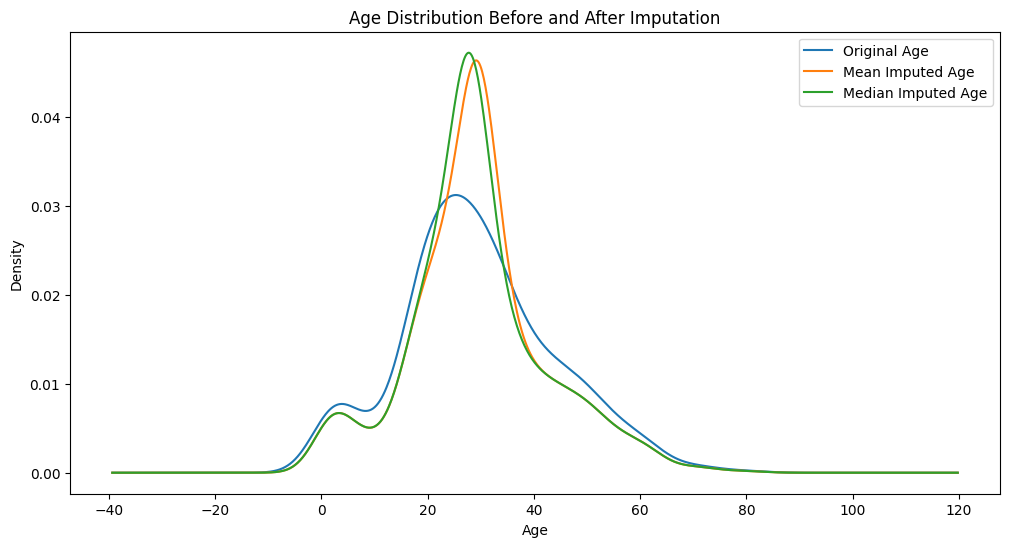

In [12]:
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 1, 1)

x_train['Age'].plot(kind='kde', label='Original Age')
x_train['Mean_age'].plot(kind='kde', label='Mean Imputed Age')
x_train['Median_age'].plot(kind='kde', label='Median Imputed Age')
plt.legend()
plt.title('Age Distribution Before and After Imputation')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

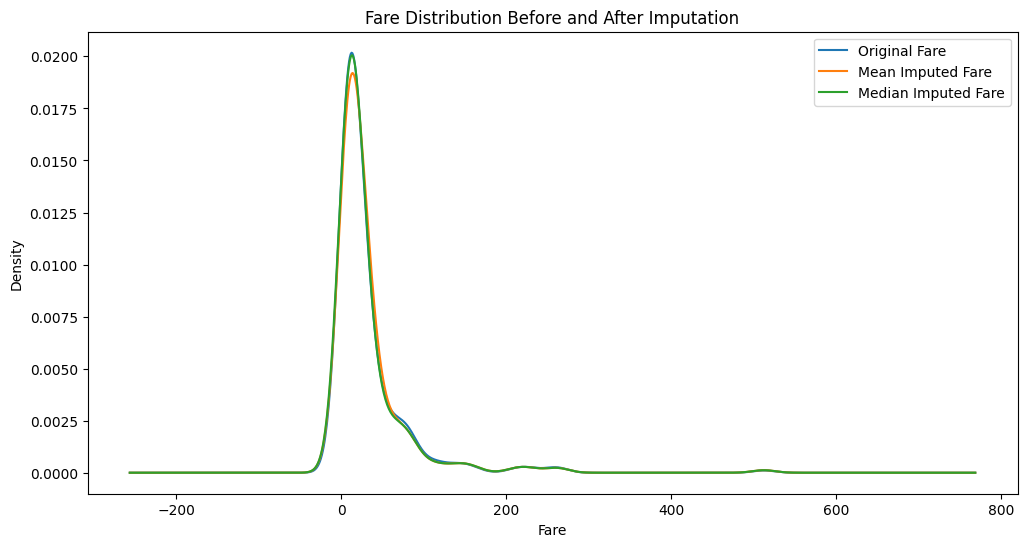

In [13]:
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 1, 1)

df['Fare'].plot(kind='kde', label='Original Fare')
x_train['Mean_fare'].plot(kind='kde', label='Mean Imputed Fare')
x_train['Median_fare'].plot(kind='kde', label='Median Imputed Fare')
plt.legend()
plt.title('Fare Distribution Before and After Imputation')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()

The correlation and covarince between the columns.

In [14]:
x_train.cov() # Tells us how two variables vary together. A positive covariance indicates that the variables tend to increase or decrease together, while a negative covariance indicates that one variable tends to increase when the other decreases. The magnitude of the covariance indicates the strength of the relationship between the variables, but it is not standardized and can be difficult to interpret.

,Age,Fare,Family,Mean_age,Median_age,Mean_fare,Median_fare
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
Mean_age,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
Median_age,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
Mean_fare,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
Median_fare,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [15]:
x_train.corr() # Output is the same as covariance matrix but with values between -1 and 1, which makes it easier to interpret the strength of the relationships between variables.

,Age,Fare,Family,Mean_age,Median_age,Mean_fare,Median_fare
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
Mean_age,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
Median_age,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
Mean_fare,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
Median_fare,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


Boxplot to find outliers.

<Axes: >

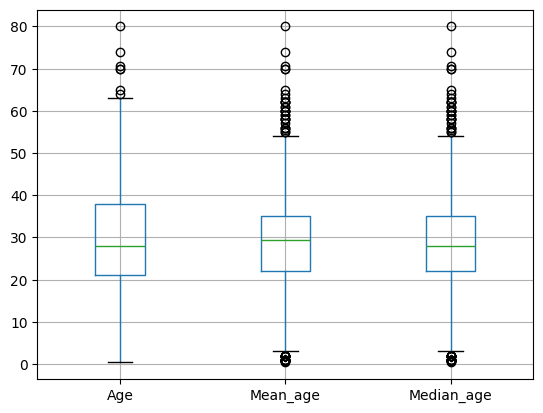

In [16]:
x_train[['Age', 'Mean_age', 'Median_age']].boxplot()

<Axes: >

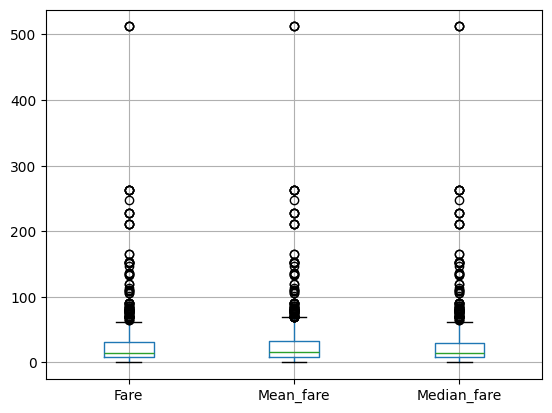

In [17]:
x_train[['Fare', 'Mean_fare', 'Median_fare']].boxplot()

Split the data into train and test.

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 3), (179, 3), (712,), (179,))

Imputation with mean and median techniques.

In [19]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

Column transformer to apply different preprocessing to different column. 

In [20]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')


Fit the data.

In [21]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


The stats of the imputers.

In [22]:
trf.named_transformers_['imputer1'].statistics_

array([29.74518389])

In [23]:
trf.named_transformers_['imputer2'].statistics_

array([14.4542])

Transforming the data.

In [24]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)
x_train


array([[29.74518389, 15.2458    ,  2.        ],
       [31.        , 10.5       ,  0.        ],
       [31.        , 37.0042    ,  2.        ],
       ...,
       [29.74518389,  7.7333    ,  0.        ],
       [36.        , 17.4       ,  1.        ],
       [60.        , 39.        ,  2.        ]], shape=(712, 3))

### II. Arbitary imputation.


Read the data.

In [25]:
df2 = pd.read_csv('Datasets/titanic_toy.csv')
df2.sample(5)

,Age,Fare,Family,Survived
587,60.0,79.200,2,1
393,23.0,113.275,1,1
770,24.0,9.500,0,0
32,NaN,7.750,0,1
376,22.0,7.250,0,1


Split the data into train and test.

In [26]:
x = df2.drop('Survived', axis=1)
y = df2['Survived']

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 3), (179, 3), (712,), (179,))

Assign arbitary (out of range) values in place of null values.

In [28]:
x_train['Age_99'] = x_train['Age'].fillna(99)
x_train['Age_-1'] = x_train['Age'].fillna(-1)
x_train['Fare_999'] = x_train['Fare'].fillna(999)
x_train['Fare_-1'] = x_train['Fare'].fillna(-1)
x_train.head()

,Age,Fare,Family,Age_99,Age_-1,Fare_999,Fare_-1
140,NaN,15.2458,2,99.0,-1.0,15.2458,15.2458
439,31.0,10.5000,0,31.0,31.0,10.5000,10.5000
817,31.0,37.0042,2,31.0,31.0,37.0042,37.0042
378,20.0,NaN,0,20.0,20.0,999.0000,-1.0000
491,21.0,7.2500,0,21.0,21.0,7.2500,7.2500


Comparisions.

In [29]:
print(f"Original Age column values: {x_train['Age'].var()}")
print(f"Age column values after imputation with 99: {x_train['Age_99'].var()}")
print(f"Age column values after imputation with -1: {x_train['Age_-1'].var()}")

Original Age column values: 213.7165085187575
Age column values after imputation with 99: 934.1249575238231
Age column values after imputation with -1: 321.6688109349073


In [30]:
print(f"Original Fare column values: {x_train['Fare'].var()}")
print(f"Fare column values after imputation with 999: {x_train['Fare_999'].var()}")
print(f"Fare column values after imputation with -1: {x_train['Fare_-1'].var()}")

Original Fare column values: 2574.352620663723
Fare column values after imputation with 999: 50926.92292430495
Fare column values after imputation with -1: 2489.213857315901


Plots.

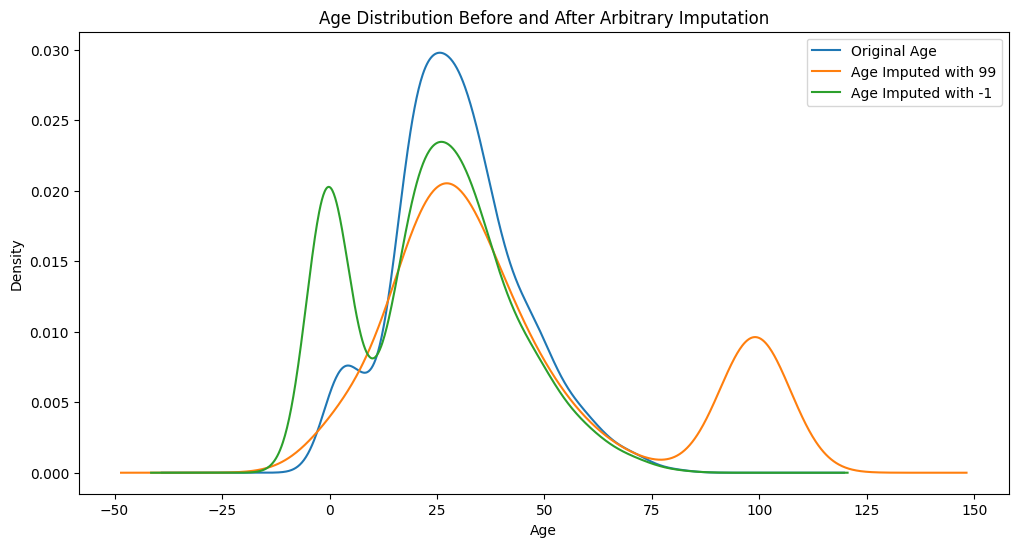

In [31]:
fig = plt.figure(figsize=(12, 6))
plt.subplot(111)

x_train['Age'].plot(kind='kde', label='Original Age')
x_train['Age_99'].plot(kind='kde', label='Age Imputed with 99')
x_train['Age_-1'].plot(kind='kde', label='Age Imputed with -1')
plt.legend()
plt.title('Age Distribution Before and After Arbitrary Imputation')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

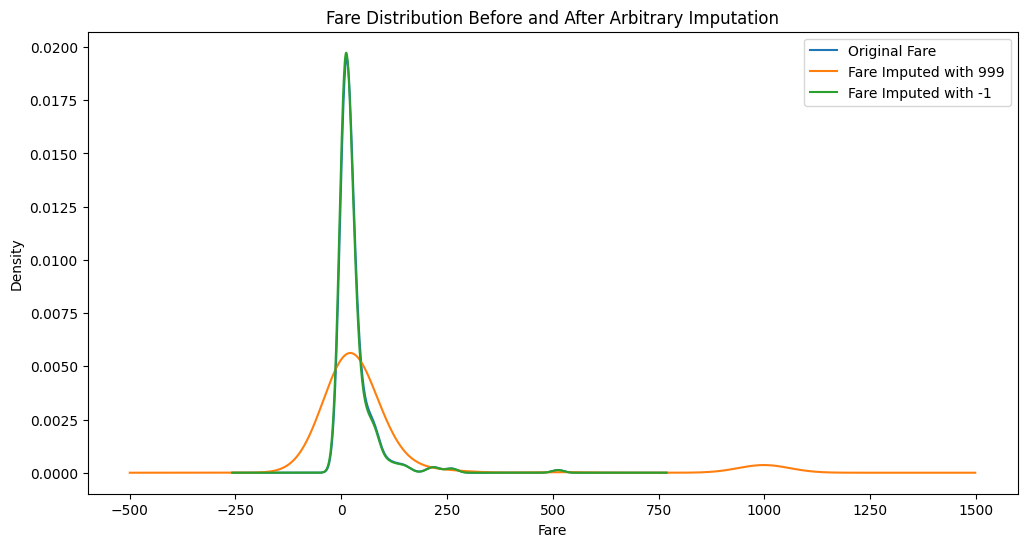

In [32]:
fig = plt.figure(figsize=(12, 6))
plt.subplot(111)

x_train['Fare'].plot(kind='kde', label='Original Fare')
x_train['Fare_999'].plot(kind='kde', label='Fare Imputed with 999')
x_train['Fare_-1'].plot(kind='kde', label='Fare Imputed with -1')
plt.legend()
plt.title('Fare Distribution Before and After Arbitrary Imputation')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()

Imputation with mean and median techniques.

In [33]:
x_train.cov()

,Age,Fare,Family,Age_99,Age_-1,Fare_999,Fare_-1
Age,213.716509,84.480223,-6.393469,213.716509,213.716509,87.899997,79.287836
Fare,84.480223,2574.352621,17.050423,-49.762911,119.548363,2574.352621,2574.352621
Family,-6.393469,17.050423,2.770177,-5.506430,-4.956484,6.685344,16.435815
Age_99,213.716509,-49.762911,-5.506430,934.124958,-167.301760,-202.695108,-41.740249
Age_-1,213.716509,119.548363,-4.956484,-167.301760,321.668811,191.737330,110.313200
Fare_999,87.899997,2574.352621,6.685344,-202.695108,191.737330,50926.922924,784.183690
Fare_-1,79.287836,2574.352621,16.435815,-41.740249,110.313200,784.183690,2489.213857


In [34]:
x_train.corr()

,Age,Fare,Family,Age_99,Age_-1,Fare_999,Fare_-1
Age,1.000000,0.106334,-0.295318,1.000000,1.000000,0.025986,0.102325
Fare,0.106334,1.000000,0.198661,-0.031926,0.130702,1.000000,1.000000
Family,-0.295318,0.198661,1.000000,-0.108247,-0.166041,0.017799,0.197928
Age_99,1.000000,-0.031926,-0.108247,1.000000,-0.305206,-0.029388,-0.027373
Age_-1,1.000000,0.130702,-0.166041,-0.305206,1.000000,0.047373,0.123280
Fare_999,0.025986,1.000000,0.017799,-0.029388,0.047373,1.000000,0.069649
Fare_-1,0.102325,1.000000,0.197928,-0.027373,0.123280,0.069649,1.000000


Split data into train and test.

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

Imputers with mean and median teachnique.

In [36]:
imputer3 = SimpleImputer(strategy='constant', fill_value=99)
imputer4 = SimpleImputer(strategy='constant', fill_value=999)

Column transformer for seperate preprocessing.

In [37]:
trf2 = ColumnTransformer([
    ('imputer3', imputer3, ['Age']),
    ('imputer4', imputer4, ['Fare'])
], remainder='passthrough')

Fit the data.

In [38]:
trf2.fit(x_train)

,transformers,"[('imputer3', ...), ('imputer4', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


Statistics of the imputers.

In [39]:
trf2.named_transformers_['imputer3'].statistics_

array([99.])

In [40]:
trf2.named_transformers_['imputer4'].statistics_

array([999.])

Transform the data.

In [41]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)
x_train

array([[29.74518389, 15.2458    ,  2.        ],
       [31.        , 10.5       ,  0.        ],
       [31.        , 37.0042    ,  2.        ],
       ...,
       [29.74518389,  7.7333    ,  0.        ],
       [36.        , 17.4       ,  1.        ],
       [60.        , 39.        ,  2.        ]], shape=(712, 3))